# Lab 8 — Sampling in Deep Learning

**Advanced Deep Learning** — 2025-2026

- **Lecture:** Prof. Ye Zhu
- **Lab:** Dr Guillaume Lachaud

---

This lab explores three fundamental sampling strategies, from classical to modern:

1. **Importance Sampling** — weight-based estimation and its high-dimensional collapse
2. **MCMC / Metropolis-Hastings** — iterative correction with convergence diagnostics
3. **Diffusion Models** — learned denoising as a sampling mechanism

In [1]:
import torch
import os

from src.sampling_lab.utils import get_device, set_seed
from src.sampling_lab.importance import (
    gaussian_importance_sampling,
    effective_sample_size,
    run_importance_sampling_experiment,
    plot_weight_distribution,
    plot_ess_vs_dimension,
)
from src.sampling_lab.mcmc import (
    make_default_mixture,
    metropolis_hastings,
    compare_step_sizes,
    plot_chain_2d,
    plot_trace,
    plot_autocorrelation,
    plot_step_size_comparison,
)
from src.sampling_lab.diffusion import (
    load_pretrained,
    make_moons_dataset,
    ddpm_sample,
    ddim_sample,
    plot_samples,
    plot_trajectory,
    plot_ddpm_vs_ddim,
    plot_steps_degradation,
)

set_seed(42)
device = get_device()
print(f"Device: {device} | PyTorch: {torch.__version__}")

Device: cuda | PyTorch: 2.5.1


---
# Act 1: Importance Sampling (~30 min)

## The Idea

We want to estimate $\mathbb{E}_{p}[f(x)]$ but can't sample directly from $p$.
Instead, we sample from a **proposal** distribution $q$ and re-weight:

$$\mathbb{E}_{p}[f(x)] = \mathbb{E}_{q}\left[f(x) \cdot \frac{p(x)}{q(x)}\right] \approx \frac{1}{N}\sum_{i=1}^{N} f(x_i) \cdot w_i, \quad x_i \sim q$$

where $w_i = p(x_i) / q(x_i)$ are the **importance weights**.

## The Problem

When $p$ and $q$ don't overlap well, most weights become negligible and a few dominate.
This **weight collapse** gets exponentially worse in high dimensions.

## Effective Sample Size (ESS)

The **ESS** measures how many "useful" samples we actually have:

$$\text{ESS} = \frac{1}{\sum_{i=1}^N \hat{w}_i^2}$$

where $\hat{w}_i$ are normalized weights (summing to 1). If $\text{ESS} \approx N$, all samples contribute equally. If $\text{ESS} \approx 1$, one sample dominates.

### Your task

Open `src/sampling_lab/importance.py` and implement the `effective_sample_size` function.

In [2]:
def test_ess():
    _uniform_w = torch.ones(1000) / 1000
    _ess_uniform = effective_sample_size(_uniform_w)

    _peaked_w = torch.zeros(1000)
    _peaked_w[0] = 1.0
    _ess_peaked = effective_sample_size(_peaked_w)

    _ess_u = _ess_uniform.item() if isinstance(_ess_uniform, torch.Tensor) else _ess_uniform
    _ess_p = _ess_peaked.item() if isinstance(_ess_peaked, torch.Tensor) else _ess_peaked

    if abs(_ess_u - 1000) < 1 and abs(_ess_p - 1) < 0.1:
        print(f"SUCCESS: ESS test passed! Uniform: {_ess_u:.0f}, Peaked: {_ess_p:.1f}")
    elif _ess_u == 0 and _ess_p == 0:
        print("WARNING: ESS is 0.0. Implement effective_sample_size.")
    else:
        print(f"FAILED: Uniform: {_ess_u:.1f}, Peaked: {_ess_p:.1f}")

test_ess()

tensor(999.9998)
tensor(1.)
SUCCESS: ESS test passed! Uniform: 1000, Peaked: 1.0


### Interactive Explorer

Modify the `dim_val` and `offset_val` parameters below to explore how **dimension** and **target offset** affect the importance weights. The proposal is always $\mathcal{N}(0, I)$ and the target is $\mathcal{N}(\mu \cdot \mathbf{1}, I)$ where $\mu$ is the offset.

tensor(3696.5286)
ESS = 3697 / 10,000 (37.0%) — Estimate = 1.000 (true = 1.0)


C:\Users\Alexander\AppData\Local\Temp\ipykernel_36800\2907444205.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


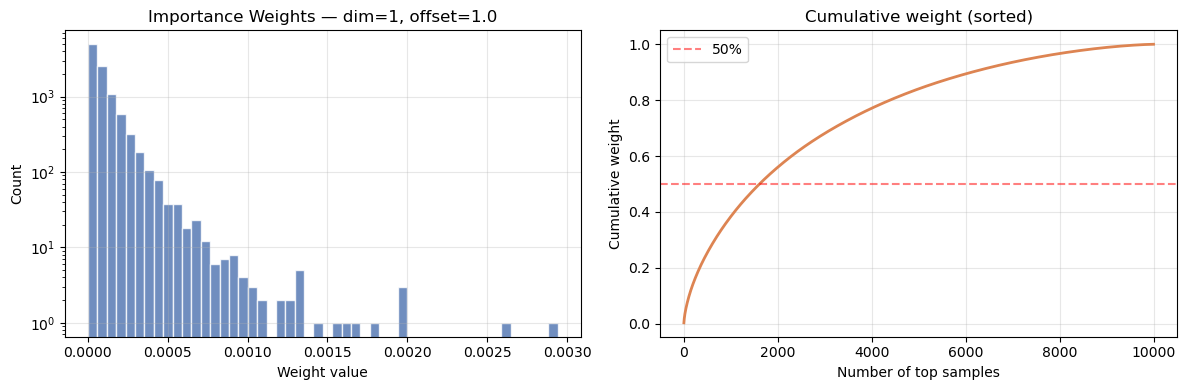

In [7]:
# Paramètres (remplacent les sliders Marimo)
dim_val = 1 
offset_val = 1.0 

if dim_val == 1:
    _proposal = torch.distributions.Normal(loc=0.0, scale=1.0)
    def _target_log_prob(x):
        return torch.distributions.Normal(loc=offset_val, scale=1.0).log_prob(x)
else:
    _proposal = torch.distributions.MultivariateNormal(
        loc=torch.zeros(dim_val), covariance_matrix=torch.eye(dim_val),
    )
    _mean = torch.full((dim_val,), offset_val)
    def _target_log_prob(x, mean=_mean):
        diff = x - mean
        return -0.5 * (diff * diff).sum(dim=-1)

def _f(x):
    return torch.ones(x.shape[0]) if x.dim() > 1 else torch.ones_like(x)

_est, _w, _ = gaussian_importance_sampling(_f, _target_log_prob, _proposal, n_samples=10000)
_ess = effective_sample_size(_w)
_ess_val = _ess.item() if isinstance(_ess, torch.Tensor) else _ess
_ess_pct = _ess_val / 10000 * 100

print(f"ESS = {_ess_val:.0f} / 10,000 ({_ess_pct:.1f}%) — Estimate = {_est.item():.3f} (true = 1.0)")

_fig = plot_weight_distribution(_w, title=f"Importance Weights — dim={dim_val}, offset={offset_val}")
_fig.show()

### Summary: ESS vs Dimension

The plot below runs a full sweep to show the collapse trend.

tensor(109.9531)
tensor(6.5754)
tensor(5.0505)
tensor(4.8407)
tensor(1.0683)
tensor(1.0000)


C:\Users\Alexander\AppData\Local\Temp\ipykernel_36800\1447515992.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


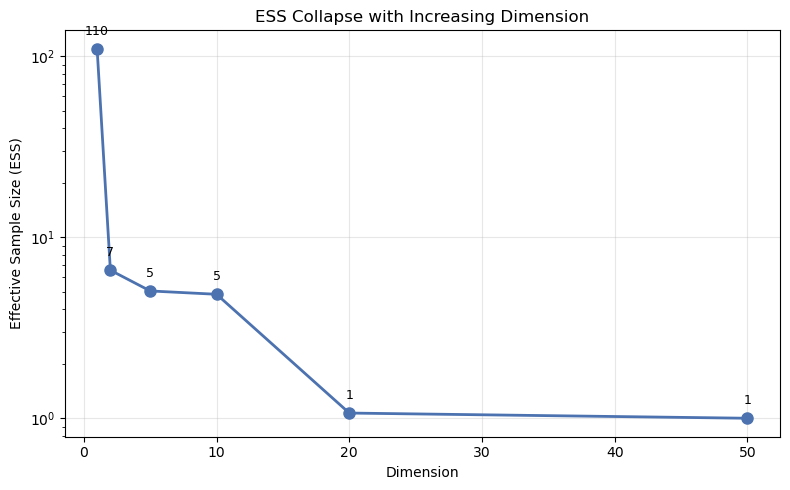

In [8]:
os.makedirs("plots", exist_ok=True)
_results = run_importance_sampling_experiment(
    dims=[1, 2, 5, 10, 20, 50],
    n_samples=10000,
    target_offset=3.0,
)
_fig = plot_ess_vs_dimension(_results)
_fig.savefig("plots/act1_ess_vs_dim.pdf", bbox_inches="tight")
_fig.show()

**Q1:** Why does importance sampling collapse in high dimensions? What role does ESS play as a diagnostic?

L'effondrement de l'échantillonnage préférentiel en grande dimension s'explique mathématiquement par la concentration de la mesure et la croissance exponentielle de la variance des poids.
$ w(x) = \frac{p(x)}{q(x)} = \prod_{i=1}^d \frac{p(x_i)}{q(x_i)} $ 

Si $\text{ESS} \approx N$ : $\hat{w}_i \approx \frac{1}{N}$ pour tout $i$. La proposition $q(x)$ correspond bien à $p(x)$. Tous les échantillons contribuent à l'estimation.Si $\text{ESS} \approx 1$ : Un seul poids normalisé vaut $\approx 1$ et tous les autres valent $\approx 0$. C'est le signal clair d'un effondrement. L'estimation repose sur un point unique et n'a aucune validité statistique.

---
# Act 2: MCMC / Metropolis-Hastings (~35 min)

## The Idea

Instead of weighting samples from a fixed proposal, we build a **Markov chain**
whose stationary distribution is the target $p(x)$.

The **Metropolis-Hastings** algorithm:

1. Start at some point $x_0$
2. Propose: $x' = x_t + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$
3. Compute acceptance ratio: $\alpha = \min\left(1, \frac{p(x')}{p(x_t)}\right)$
4. Accept $x_{t+1} = x'$ with probability $\alpha$, otherwise $x_{t+1} = x_t$
5. Repeat

The chain converges to sampling from $p$ regardless of the starting point (in theory).

## Key Diagnostic: Step Size

- **Too small** $\sigma$: high acceptance rate but slow exploration (chain "sticks")
- **Too large** $\sigma$: low acceptance rate, many rejections, also slow
- **Sweet spot**: ~25-50% acceptance rate (for high-dimensional targets)

### Your task

Open `src/sampling_lab/mcmc.py` and implement the accept/reject step in `metropolis_hastings`.

In [2]:
def test_mh():
    _target_log_prob, _, _ = make_default_mixture()
    _x_init = torch.zeros(2)

    _chain, _acc = metropolis_hastings(
        _target_log_prob, _x_init, n_steps=2000, proposal_std=0.8,
    )

    if _acc == 0.0:
        print("WARNING: Acceptance rate is 0%. Implement the MH accept/reject step.")
    elif _acc < 0.05:
        print(f"FAILED: Acceptance rate = {_acc:.1%} — very low. Check your logic.")
    else:
        print(f"SUCCESS: Acceptance rate = {_acc:.1%} — chain is running!")

test_mh()

SUCCESS: Acceptance rate = 52.2% — chain is running!


### Interactive Explorer

Modify `sigma_val` below and watch how the chain, trace plot, and autocorrelation change.
Look for the sweet spot between too-cautious and too-aggressive proposals.

Acceptance rate: 85.8%


C:\Users\Alexander\AppData\Local\Temp\ipykernel_22428\3981369566.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig_chain.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_22428\3981369566.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig_trace.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_22428\3981369566.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig_acf.show()


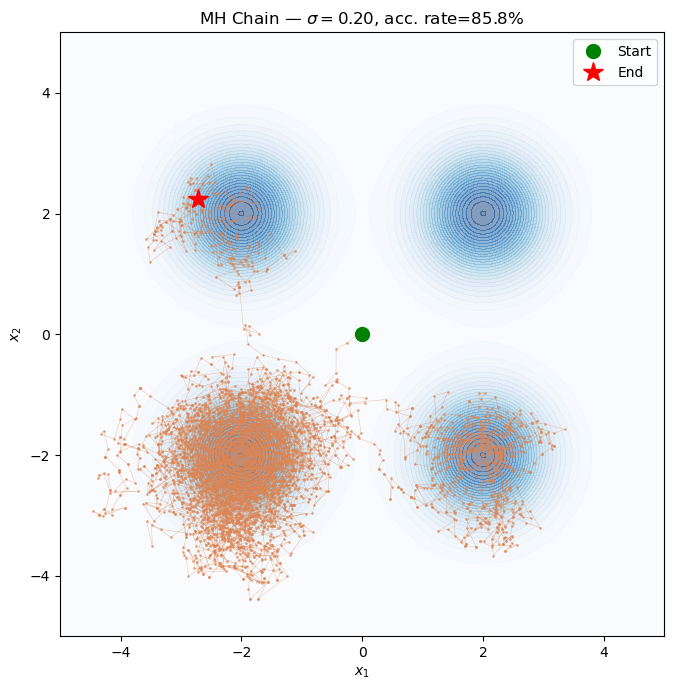

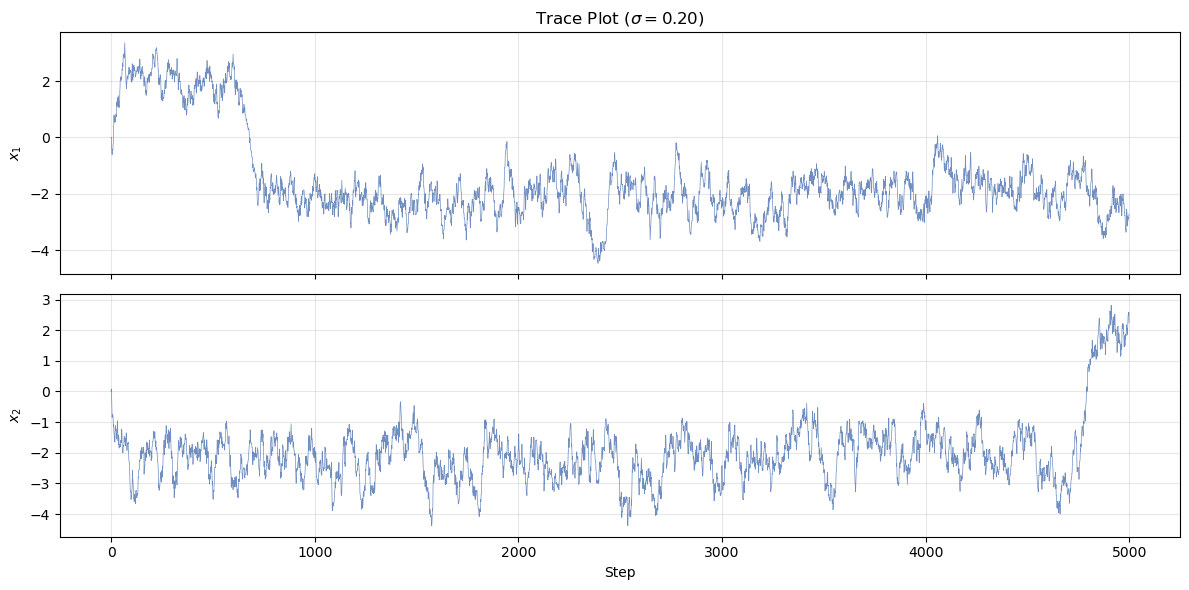

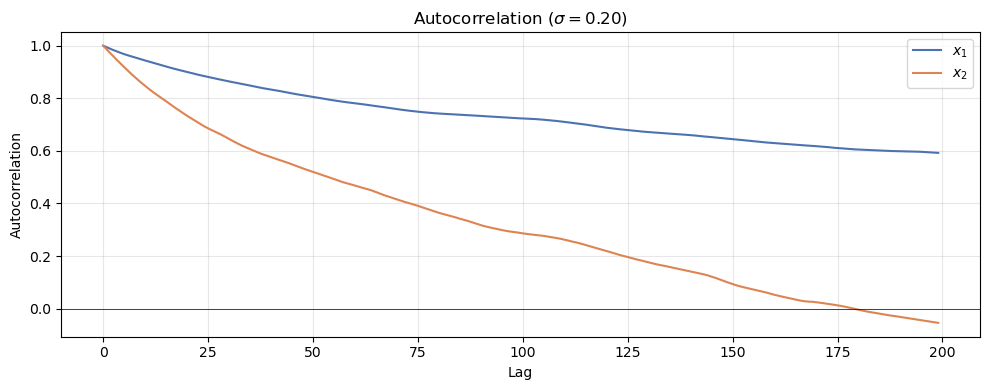

In [7]:
# Paramètre (remplace le slider Marimo)
sigma_val = 0.2

_target_log_prob, _, _ = make_default_mixture()
_x_init = torch.zeros(2)

_chain, _acc = metropolis_hastings(
    _target_log_prob, _x_init, n_steps=5000, proposal_std=sigma_val,
)

print(f"Acceptance rate: {_acc:.1%}")

_fig_chain = plot_chain_2d(_chain, target_log_prob=_target_log_prob, title=f"MH Chain — $\sigma={sigma_val:.2f}$, acc. rate={_acc:.1%}")
_fig_trace = plot_trace(_chain, title=f"Trace Plot ($\sigma={sigma_val:.2f}$)")
_fig_acf = plot_autocorrelation(_chain, max_lag=200, title=f"Autocorrelation ($\sigma={sigma_val:.2f}$)")

_fig_chain.show()
_fig_trace.show()
_fig_acf.show()

### Summary: Step Size Comparison

Side-by-side view of four different step sizes for quick comparison.

| Step size (σ) | Acceptance rate |
|---|---|
| 0.05 | 96.8% |
| 0.5 | 68.2% |
| 2.0 | 27.2% |
| 10.0 | 4.0% |


C:\Users\Alexander\AppData\Local\Temp\ipykernel_22428\2738414275.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


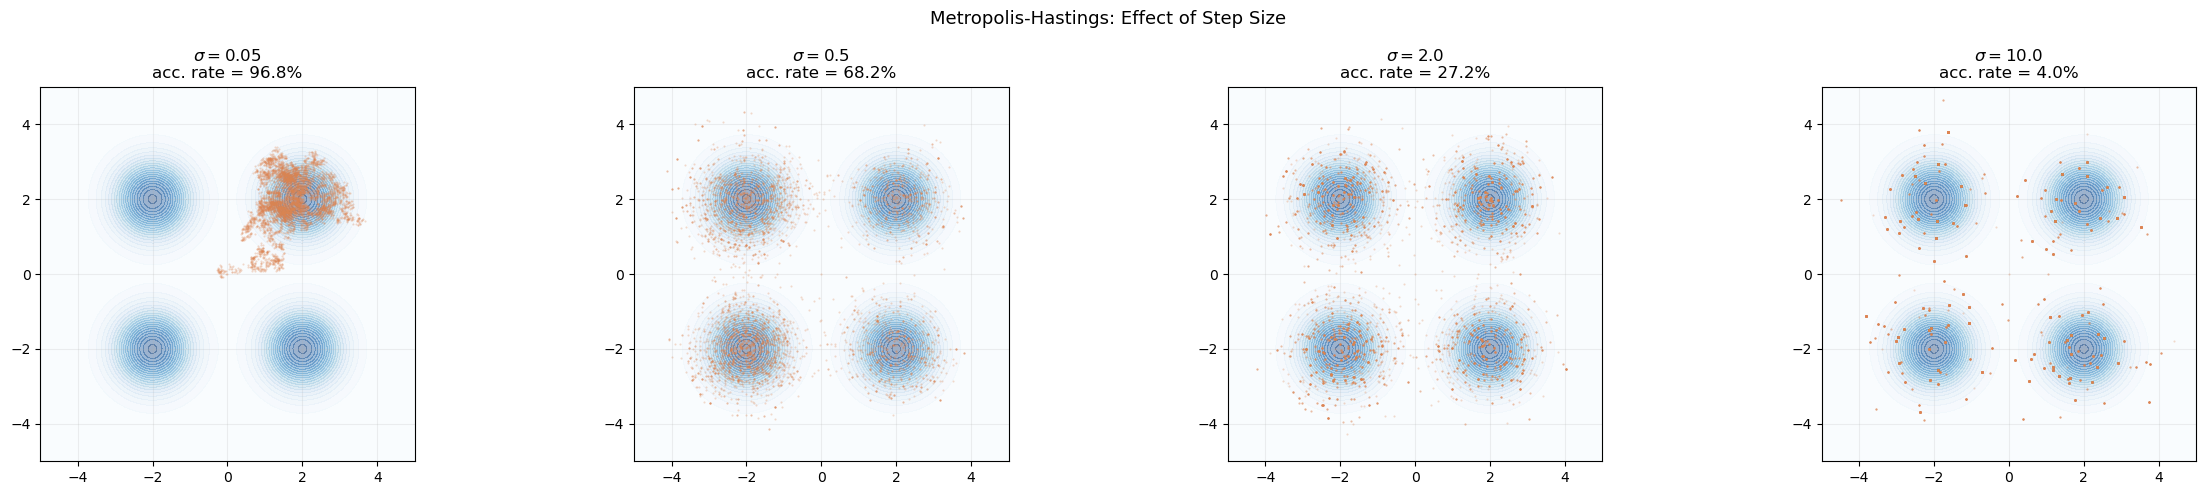

In [8]:
os.makedirs("plots", exist_ok=True)
_target_log_prob, _, _ = make_default_mixture()
_x_init = torch.zeros(2)

_results = compare_step_sizes(
    _target_log_prob,
    step_sizes=[0.05, 0.5, 2.0, 10.0],
    x_init=_x_init,
    n_steps=5000,
)
_fig = plot_step_size_comparison(_results, target_log_prob=_target_log_prob)
_fig.savefig("plots/act2_step_sizes.pdf", bbox_inches="tight")
_fig.show()

print("| Step size (\u03c3) | Acceptance rate |")
print("|---|---|")
for _r in _results:
    print(f"| {_r['step_size']} | {_r['acceptance_rate']:.1%} |")

**Q2:** What is the relationship between step size, acceptance rate, and mixing quality? How would you choose a good step size in practice?

Dans l'algorithme de Metropolis-Hastings avec une proposition de type marche aléatoire $ q(x'|x) = \mathcal{N}(x, \sigma^2 I) $ , la taille de pas $\sigma$ dicte l'efficacité de l'exploration de la chaîne de Markov. La qualité de mélange dépend directement du compromis entre la distance proposée et la probabilité de l'accepter.

---
# Act 3: Diffusion Sampling (~45 min)

## The Idea

Diffusion models define a **forward process** that gradually adds noise to data:

$$q(x_t | x_0) = \mathcal{N}\left(x_t; \sqrt{\bar{\alpha}_t}\, x_0,\; (1 - \bar{\alpha}_t)\, I\right)$$

and learn a **reverse process** that denoises step by step:

$$p_\theta(x_{t-1} | x_t) \approx \mathcal{N}\left(x_{t-1}; \mu_\theta(x_t, t),\; \sigma_t^2 I\right)$$

A neural network $\epsilon_\theta(x_t, t)$ is trained to predict the noise added at each step.

## DDPM vs DDIM

- **DDPM** (Denoising Diffusion Probabilistic Models): stochastic reverse process, goes through all $T$ steps
- **DDIM** (Denoising Diffusion Implicit Models): deterministic reverse process, can **skip steps** for faster sampling

The DDIM update (with $\eta = 0$, deterministic):

$$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t}\, \epsilon_\theta(x_t, t)}{\sqrt{\bar{\alpha}_t}}$$

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\, \hat{x}_0 + \sqrt{1 - \bar{\alpha}_{t-1}}\, \epsilon_\theta(x_t, t)$$

### Your task

Open `src/sampling_lab/diffusion.py` and implement the DDIM update step in `ddim_sample`.

> **Note:** You need a pre-trained model at `checkpoints/score_net_moons.safetensors`.

In [2]:
_ckpt_dir = "checkpoints"
_model_ok = (
    os.path.exists(os.path.join(_ckpt_dir, "score_net_moons.safetensors"))
    and os.path.exists(os.path.join(_ckpt_dir, "schedule.pt"))
)

if not _model_ok:
    raise FileNotFoundError("Pre-trained model not found in checkpoints/.")

diff_model, diff_betas, diff_alphas_cumprod, diff_n_steps = load_pretrained(
    checkpoint_dir=_ckpt_dir, device=device,
)
reference_data = make_moons_dataset(n_samples=2000)

print(f"Diffusion steps: {diff_n_steps}")
print(f"Model parameters: {sum(p.numel() for p in diff_model.parameters()):,}")

Diffusion steps: 200
Model parameters: 75,778


C:\Users\Alexander\AppData\Local\Temp\ipykernel_28792\1267722592.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


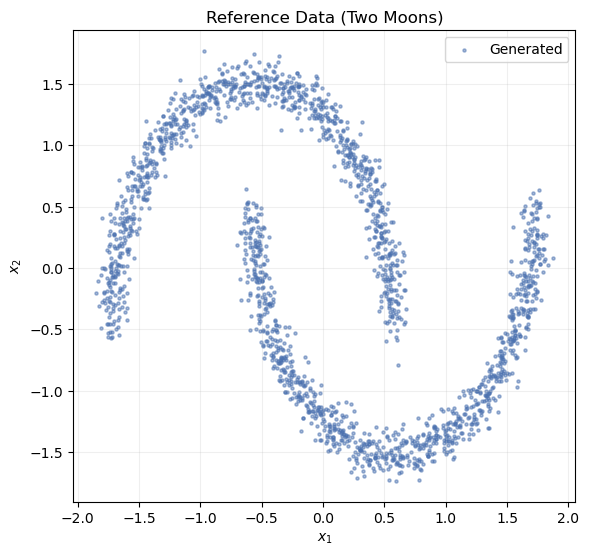

In [3]:
_fig = plot_samples(reference_data, title="Reference Data (Two Moons)")
_fig.show()

### DDPM Sampling

First, let's generate samples using the full DDPM reverse process (all T steps).

C:\Users\Alexander\AppData\Local\Temp\ipykernel_28792\1406365883.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


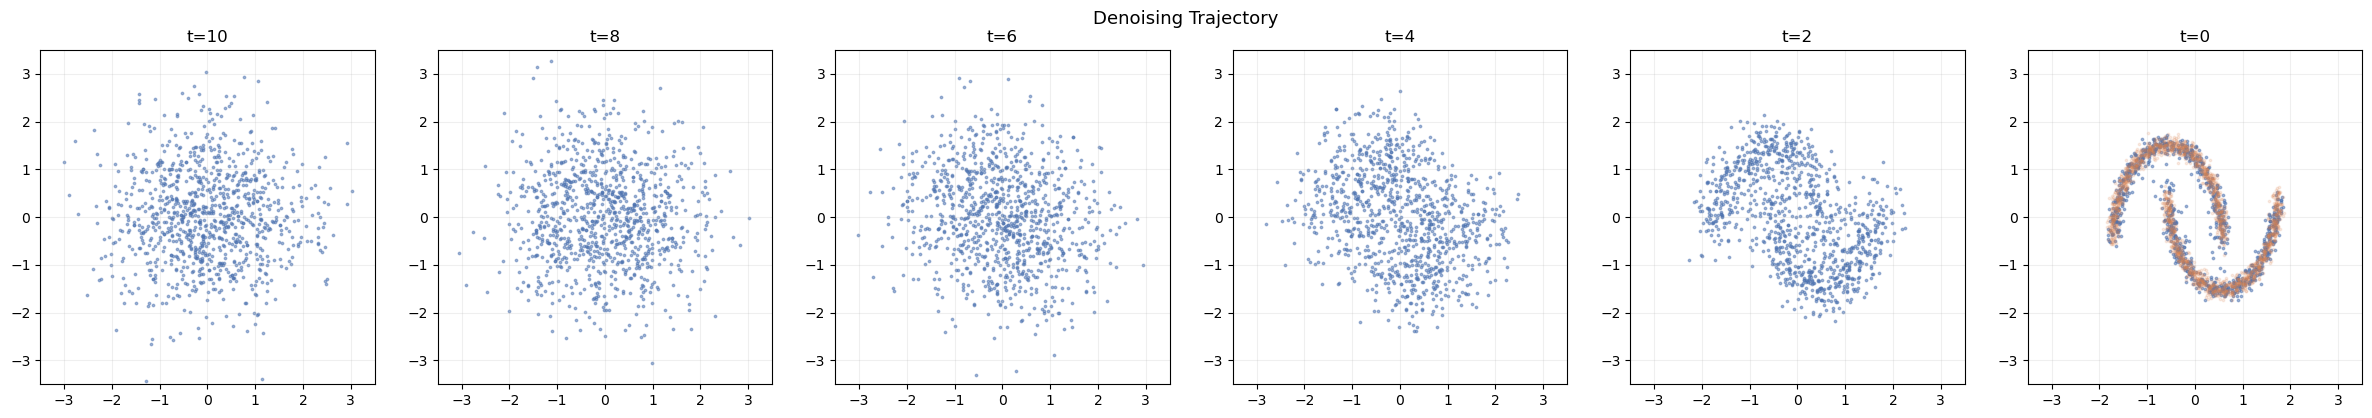

In [4]:
os.makedirs("plots", exist_ok=True)
ddpm_samples, ddpm_traj = ddpm_sample(
    diff_model, diff_betas, diff_alphas_cumprod,
    n_samples=1000, device=device,
)
_fig = plot_trajectory(ddpm_traj, n_snapshots=6, reference=reference_data)
_fig.savefig("plots/act3_trajectory.pdf", bbox_inches="tight")
_fig.show()

In [5]:
def test_ddim():
    _samples, _traj = ddim_sample(
        diff_model, diff_alphas_cumprod,
        n_steps_total=diff_n_steps,
        n_steps_sample=50,
        n_samples=500,
        device=device,
    )
    
    _first = _traj[0] if len(_traj) > 0 else None
    _last = _traj[-1] if len(_traj) > 0 else None
    if _first is not None and _last is not None:
        _diff = (_first - _last).abs().mean().item()
        if _diff < 0.01:
            print("WARNING: DDIM samples look like pure noise. Implement the update step.")
        else:
            print(f"SUCCESS: DDIM sampling is working (using 50 steps instead of {diff_n_steps}).")
    else:
        print("Could not verify DDIM output.")

test_ddim()

SUCCESS: DDIM sampling is working (using 50 steps instead of 200).


C:\Users\Alexander\AppData\Local\Temp\ipykernel_28792\1216334960.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


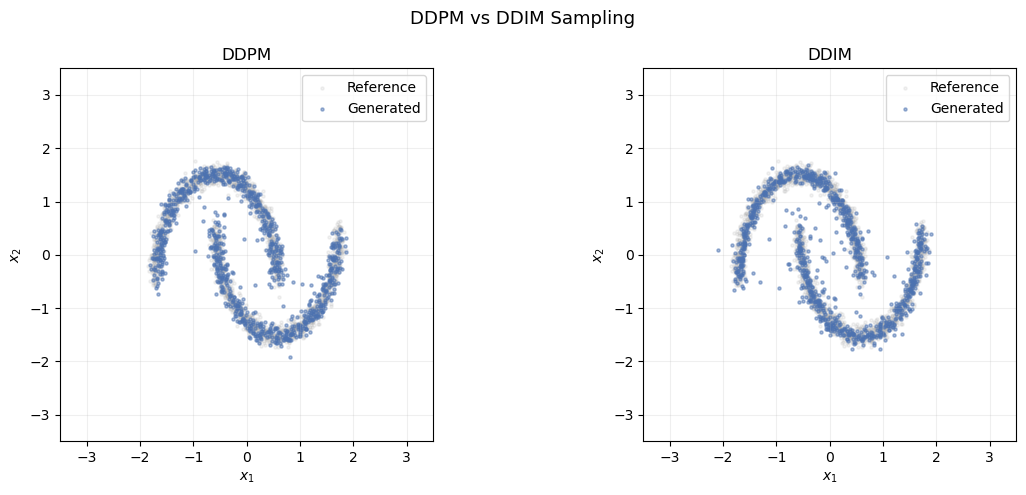

In [6]:
os.makedirs("plots", exist_ok=True)
_ddpm, _ = ddpm_sample(
    diff_model, diff_betas, diff_alphas_cumprod,
    n_samples=1000, device=device,
)
_ddim, _ = ddim_sample(
    diff_model, diff_alphas_cumprod,
    n_steps_total=diff_n_steps, n_steps_sample=50,
    n_samples=1000, device=device,
)
_fig = plot_ddpm_vs_ddim(_ddpm, _ddim, reference=reference_data)
_fig.savefig("plots/act3_ddpm_vs_ddim.pdf", bbox_inches="tight")
_fig.show()

### DDIM Step Count Analysis

Modify `steps_val` below to see how reducing the number of DDIM steps degrades sample quality. Fewer steps = faster generation, but at what cost?

C:\Users\Alexander\AppData\Local\Temp\ipykernel_28792\2725564889.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  _fig.show()


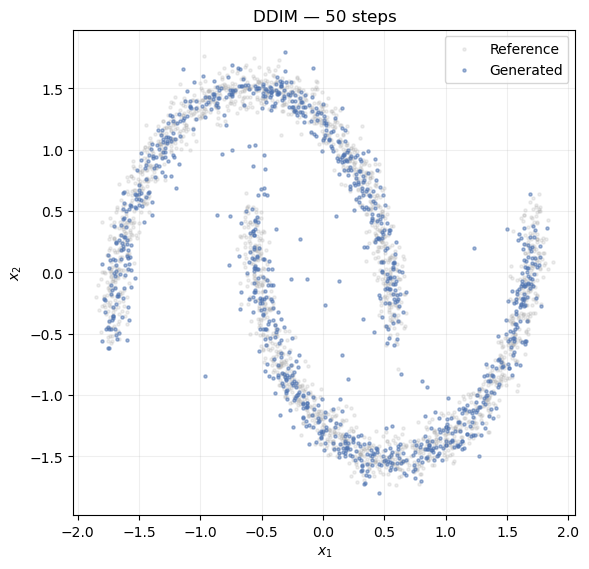

In [7]:
# Paramètre (remplace le slider Marimo)
steps_val = 50

_samples, _ = ddim_sample(
    diff_model, diff_alphas_cumprod,
    n_steps_total=diff_n_steps,
    n_steps_sample=steps_val,
    n_samples=1000,
    device=device,
)
_fig = plot_samples(_samples, title=f"DDIM — {steps_val} steps", reference=reference_data)
_fig.show()

**Q3:** Compare DDPM and DDIM. What are the trade-offs between sample quality and speed? How few DDIM steps can you use before quality visibly degrades?

DDPM repose sur un processus de Markov stochastique nécessitant d'itérer sur l'intégralité des $T$ pas d'inférence, ce qui garantit une haute fidélité mais une exécution très lente. À l'inverse, DDIM redéfinit le processus inverse comme une équation différentielle ordinaire implicite et déterministe. Cette formulation permet de "sauter" des étapes d'intégration de manière consistante. Le compromis fondamental oppose donc le temps de calcul (accéléré par DDIM) à la finesse de modélisation stochastique (maximisée par DDPM).

En pratique, l'échantillonnage DDIM permet de réduire le nombre de pas d'un facteur 10 à 50 (ex: de 1000 à 50 pas) sans baisse significative de fidélité. La dégradation visuelle (flou, perte de cohérence globale) devient critique en dessous du seuil de 10 à 20 pas, seuil à partir duquel l'erreur de troncature dans l'intégration numérique de l'ODE devient trop importante pour être négligée.

---
# Synthesis

**Q4:** Importance sampling collapses in high dimensions, yet diffusion models generate high-dimensional images. What is the key insight that makes diffusion work where IS fails?

 L'échantillonnage préférentiel échoue en grande dimension car il tente de relier directement une distribution de proposition simple à une distribution cible multimodale complexe en une seule évaluation. La malédiction de la dimensionnalité rend le chevauchement (KL-divergence) entre ces deux distributions infinitésimal, provoquant la dégénérescence immédiate de la variance des poids.
 
 L'innovation mathématique des modèles de diffusion est la décomposition de cette transformation intraitable en une chaîne de Markov temporelle constituée de petites perturbations. À chaque pas infinitésimal, les distributions marginales $q(x_{t-1}|x_t)$ et $p_\theta(x_{t-1}|x_t)$ sont virtuellement des Gaussiennes isotropes avec un fort chevauchement. La diffusion résout l'effondrement de la dimensionnalité en remplaçant un saut global topologiquement impossible par l'intégration d'un champ de vecteurs (comme le score) sur de multiples étapes locales et traitables.